# DATAFLOW 2026 - User Behavior Prediction
## Part 3: Model Training & Evaluation

---

### Data Policy — STRICT RULE (must never be violated)

| Rule | Detail |
|------|--------|
| Training data | Only `X_train` / `Y_train` used to fit all models and preprocessors |
| Early stopping | **Internal 90/10 split from `X_train`** — `Y_val` is NEVER used for early stopping |
| Evaluation | `X_val / Y_val` used **only after training** to compute offline metrics |
| `merge_train_val()` | **NEVER called** — submission is generated from the model trained on `X_train` only |
| Submission | `predict(X_test)` with model trained on `X_train` |

---

### Notebook Contents
1. Model 1: XGBoost (ML)
2. Model 2: LightGBM (ML)
3. Model 3: LSTM (DL)
4. Model 4: Transformer
5. Model 5: Ensemble (weighted soft-voting)
6. Model Comparison
7. Submission Generation

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import torch

from src.data import DataLoader
from src.data.preprocessor import SequencePreprocessor, TargetEncoder, extract_sequences_from_df
from src.features import FeaturePipeline
from src.models import XGBoostMultiOutput, LSTMMultiOutput, TransformerMultiOutput
from src.models.ensemble_model import EnsembleMultiOutput
from src.evaluation import evaluate_model, exact_match_accuracy, analyze_errors
from src.utils import set_seed, load_config

# Create output directories
Path('../outputs/figures').mkdir(parents=True, exist_ok=True)
Path('../outputs/models').mkdir(parents=True, exist_ok=True)
Path('../outputs/submissions').mkdir(parents=True, exist_ok=True)

set_seed(42)
%matplotlib inline

# ============ GPU DIAGNOSTICS ============
print("=" * 50)
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda if torch.cuda.is_available() else "N/A")

if torch.cuda.is_available():
    DEVICE = "cuda"
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    DEVICE = "cpu"
    print("WARNING: NO GPU DETECTED - Training will be slow!")
print("=" * 50)
print(f"\nUsing device: {DEVICE}")

PyTorch version: 2.5.1+cu121
CUDA available: True
CUDA version: 12.1
GPU: Quadro T1000
Memory: 4.3 GB

Using device: cuda


In [2]:
# Load configuration and data
config = load_config('../configs/config.yaml')
loader = DataLoader('../data')

X_train_df, Y_train_df = loader.load_train()
X_val_df, Y_val_df = loader.load_val()
X_test_df = loader.load_test()

# Extract sequences
train_ids, train_sequences = extract_sequences_from_df(X_train_df)
val_ids, val_sequences = extract_sequences_from_df(X_val_df)
test_ids, test_sequences = extract_sequences_from_df(X_test_df)

2026-03-02 09:21:26,058 - src.data.loader - INFO - Loaded X_train.csv: (51000, 38)
2026-03-02 09:21:26,107 - src.data.loader - INFO - Loaded Y_train.csv: (51000, 7)
2026-03-02 09:21:26,108 - src.data.loader - INFO - Loaded training data: X=51000, Y=51000
2026-03-02 09:21:26,136 - src.data.loader - INFO - Loaded X_val.csv: (7200, 38)
2026-03-02 09:21:26,163 - src.data.loader - INFO - Loaded Y_val.csv: (7200, 7)
2026-03-02 09:21:26,163 - src.data.loader - INFO - Loaded validation data: X=7200, Y=7200
2026-03-02 09:21:26,286 - src.data.loader - INFO - Loaded X_test.csv: (38000, 38)
2026-03-02 09:21:26,286 - src.data.loader - INFO - Loaded test data: X=38000


In [3]:
from sklearn.model_selection import train_test_split

# ------------------------------------------------------------------
# DATA SPLIT POLICY (enforced here)
# ------------------------------------------------------------------
# All preprocessors are fit ONLY on train_sequences / Y_train_df.
# X_val / Y_val are held out entirely — used only for final evaluation.
# Early stopping uses an internal 90/10 split of X_train (es = early-stop).
# merge_train_val() is NEVER called.
# ------------------------------------------------------------------

# 1. Sequence preprocessing (for LSTM / Transformer)
#    Fit ONLY on train_sequences
seq_preprocessor = SequencePreprocessor(
    max_length=config['preprocessing']['max_sequence_length'],   # 64
    padding_strategy=config['preprocessing']['padding_strategy'],
    truncation_strategy=config['preprocessing']['truncation_strategy'],
)
X_train_seq = seq_preprocessor.fit_transform(train_sequences)   # fit on train only
X_val_seq   = seq_preprocessor.transform(val_sequences)          # transform only
X_test_seq  = seq_preprocessor.transform(test_sequences)         # transform only
vocab_size  = seq_preprocessor.vocab_size

# 2. Feature extraction (for XGBoost / LightGBM)
#    Fit ONLY on train_sequences
feature_pipeline = FeaturePipeline(
    use_tfidf=config['features'].get('use_tfidf', True),
    use_ngrams=config['features'].get('use_ngrams', True),
    use_statistics=config['features'].get('use_statistics', True),
    use_histogram=config['features'].get('use_histogram', True),
    ngram_range=tuple(config['features'].get('ngram_range', [1, 3])),
    max_features=config['features'].get('max_features', 5000),
    top_k_actions=config['features'].get('top_k_actions', 100),
)
X_train_features = feature_pipeline.fit_transform(train_sequences)   # fit on train only
X_val_features   = feature_pipeline.transform(val_sequences)
X_test_features  = feature_pipeline.transform(test_sequences)

# 3. Target encoding — fit ONLY on Y_train_df
target_encoder = TargetEncoder(DataLoader.TARGET_COLS)
y_train = target_encoder.fit_transform(Y_train_df)   # fit on train only
y_val   = target_encoder.transform(Y_val_df)         # transform only (held-out)

# 4. Internal early-stop split from X_train (90% train / 10% ES)
#    This split is used by XGBoost, LSTM, Transformer for early stopping.
#    Y_val is NEVER used for early stopping.
(
    X_es_seq, X_train_seq_core,
    X_es_feat, X_train_feat_core,
    y_es, y_train_core,
    es_seqs, core_seqs,
) = train_test_split(
    X_train_seq, X_train_features, y_train, train_sequences,
    test_size=0.9, random_state=42, shuffle=True,
)
# Rename for clarity: _core = training data, _es = internal early-stop monitor
X_train_seq_core,  X_es_seq  = X_train_seq_core,  X_es_seq
X_train_feat_core, X_es_feat = X_train_feat_core, X_es_feat
y_train_core,      y_es      = y_train_core,      y_es

print(f"Sequence shapes   : train={X_train_seq.shape}, val={X_val_seq.shape}, test={X_test_seq.shape}")
print(f"Feature shapes    : train={X_train_features.shape}, val={X_val_features.shape}")
print(f"Target shapes     : train={y_train.shape}, val={y_val.shape}")
print(f"Internal ES split : core={X_train_seq_core.shape[0]} samples, es={X_es_seq.shape[0]} samples")
print(f"Vocabulary size   : {vocab_size}")

2026-03-02 09:21:55,947 - src.data.preprocessor - INFO - Fitted preprocessor: 254 unique tokens → dense vocab_size=255 (was 24439 with raw IDs)
2026-03-02 09:21:56,738 - src.features.feature_pipeline - INFO - Fitting feature pipeline on 51000 sequences...
2026-03-02 09:21:56,738 - src.features.feature_pipeline - INFO - Fitting tfidf extractor...
2026-03-02 09:21:58,146 - src.features.sequence_features - INFO - Fitted sequence feature extractor: vocab_size=2000
2026-03-02 09:21:58,148 - src.features.feature_pipeline - INFO - Fitting ngram extractor...
2026-03-02 09:22:00,153 - src.features.sequence_features - INFO - Fitted n-gram extractor: 300 features
2026-03-02 09:22:00,156 - src.features.feature_pipeline - INFO - Fitting stats extractor...
2026-03-02 09:22:00,602 - src.features.statistical_features - INFO - Fitted statistical extractor: 100 top actions
2026-03-02 09:22:00,603 - src.features.feature_pipeline - INFO - Fitting histogram extractor...
2026-03-02 09:22:00,643 - src.featur

Sequence shapes   : train=(51000, 64), val=(7200, 64), test=(38000, 64)
Feature shapes    : train=(51000, 4042), val=(7200, 4042)
Target shapes     : train=(51000, 6), val=(7200, 6)
Internal ES split : core=45900 samples, es=5100 samples
Vocabulary size   : 255


## Model 1: XGBoost (ML)

In [4]:
import torch as _torch

xgb_cfg = config['models']['xgboost']
_device = xgb_cfg.get('device', 'cuda')
if _device == 'cuda' and not _torch.cuda.is_available():
    _device = 'hist'

# Early stopping uses X_train_feat_core / y_train_core as training data
# and X_es_feat / y_es as the internal monitor set.
# X_val_features / y_val are NOT passed here — they are held out for evaluation only.
xgb_model = XGBoostMultiOutput(
    n_estimators=xgb_cfg['n_estimators'],
    max_depth=xgb_cfg['max_depth'],
    learning_rate=xgb_cfg['learning_rate'],
    subsample=xgb_cfg['subsample'],
    colsample_bytree=xgb_cfg['colsample_bytree'],
    early_stopping_rounds=xgb_cfg['early_stopping_rounds'],
    device=_device,
    random_state=config['training']['seed'],
)

print(f"Training XGBoost on {X_train_feat_core.shape[0]} samples "
      f"(ES monitor: {X_es_feat.shape[0]} samples from internal split) ...")
xgb_model.fit(X_train_feat_core, y_train_core, X_es_feat, y_es)
print("Done!")

2026-03-02 09:23:20,604 - src.models.xgboost_model - INFO - Training xgboost_multi on 45900 samples...
2026-03-02 09:23:20,610 - src.models.xgboost_model - INFO - Training model for attr_1...


Training XGBoost on 45900 samples (ES monitor: 5100 samples from internal split) ...


2026-03-02 09:30:08,684 - src.models.xgboost_model - INFO -   attr_1: num_classes=12
2026-03-02 09:30:08,686 - src.models.xgboost_model - INFO - Training model for attr_2...
2026-03-02 09:50:24,325 - src.models.xgboost_model - INFO -   attr_2: num_classes=31
2026-03-02 09:50:24,326 - src.models.xgboost_model - INFO - Training model for attr_3...
2026-03-02 10:39:10,955 - src.models.xgboost_model - INFO -   attr_3: num_classes=99
2026-03-02 10:39:10,960 - src.models.xgboost_model - INFO - Training model for attr_4...
2026-03-02 10:46:42,624 - src.models.xgboost_model - INFO -   attr_4: num_classes=12
2026-03-02 10:46:42,628 - src.models.xgboost_model - INFO - Training model for attr_5...
2026-03-02 11:06:00,754 - src.models.xgboost_model - INFO -   attr_5: num_classes=31
2026-03-02 11:06:00,758 - src.models.xgboost_model - INFO - Training model for attr_6...
2026-03-02 11:48:53,746 - src.models.xgboost_model - INFO -   attr_6: num_classes=99
2026-03-02 11:48:53,748 - src.models.xgboost_

Done!


In [5]:
# Evaluate XGBoost on held-out validation set (never seen during training)
y_pred_xgb = xgb_model.predict(X_val_features)
xgb_results = evaluate_model(y_val, y_pred_xgb, "XGBoost")

2026-03-02 11:49:02,551 - src.evaluation.metrics - INFO - 
2026-03-02 11:49:02,552 - src.evaluation.metrics - INFO - Evaluation Results: XGBoost
2026-03-02 11:49:02,553 - src.evaluation.metrics - INFO - ============================================================
2026-03-02 11:49:02,553 - src.evaluation.metrics - INFO - Exact-Match Accuracy (Competition Metric): 0.9131
2026-03-02 11:49:02,553 - src.evaluation.metrics - INFO - Mean Attribute Accuracy: 0.9801
2026-03-02 11:49:02,554 - src.evaluation.metrics - INFO - Mean Macro F1: 0.9516
2026-03-02 11:49:02,555 - src.evaluation.metrics - INFO - 
Per-Attribute Accuracy:
2026-03-02 11:49:02,556 - src.evaluation.metrics - INFO -   attr_1: 0.9896
2026-03-02 11:49:02,557 - src.evaluation.metrics - INFO -   attr_2: 0.9826
2026-03-02 11:49:02,557 - src.evaluation.metrics - INFO -   attr_3: 0.9575
2026-03-02 11:49:02,558 - src.evaluation.metrics - INFO -   attr_4: 0.9942
2026-03-02 11:49:02,558 - src.evaluation.metrics - INFO -   attr_5: 0.9933


## Model 2: LightGBM (ML)

In [6]:
import lightgbm as lgb
from sklearn.multioutput import MultiOutputClassifier

lgb_cfg = config['models']['lightgbm']

# LightGBM GPU mode uploads the full feature matrix to VRAM
# (45 900 × 7042 × 4 bytes ≈ 1.3 GB) — OOMs on GPUs with < 6 GB.
# Force CPU instead; accuracy is identical, only slightly slower.
if DEVICE == "cuda" and torch.cuda.get_device_properties(0).total_memory / 1e9 >= 6:
    _lgb_device = lgb_cfg.get('device', 'cpu')
else:
    _lgb_device = 'cpu'

print(f"Training LightGBM on {X_train_feat_core.shape[0]} samples "
      f"(device={_lgb_device}, ES via internal split {X_es_feat.shape[0]} samples) ...")

# Per-target LGBMClassifier with early stopping on internal ES split.
# Y_val is NOT used here.
lgb_models = []
for i, col in enumerate(DataLoader.TARGET_COLS):
    clf = lgb.LGBMClassifier(
        n_estimators=lgb_cfg['n_estimators'],
        max_depth=lgb_cfg['max_depth'],
        learning_rate=lgb_cfg['learning_rate'],
        subsample=lgb_cfg['subsample'],
        colsample_bytree=lgb_cfg['colsample_bytree'],
        random_state=config['training']['seed'],
        device=_lgb_device,
        verbose=-1,
    )
    clf.fit(
        X_train_feat_core, y_train_core[:, i],
        eval_set=[(X_es_feat, y_es[:, i])],
        callbacks=[
            lgb.early_stopping(stopping_rounds=lgb_cfg['early_stopping_rounds'], verbose=False),
            lgb.log_evaluation(period=-1),
        ],
    )
    lgb_models.append(clf)
    print(f"  {col}: best_iteration={clf.best_iteration_}")

print("Done!")

Training LightGBM on 45900 samples (device=cpu, ES via internal split 5100 samples) ...
  attr_1: best_iteration=169
  attr_2: best_iteration=126
  attr_3: best_iteration=88
  attr_4: best_iteration=196
  attr_5: best_iteration=91
  attr_6: best_iteration=83
Done!


In [7]:
# Evaluate LightGBM on held-out validation set (never seen during training)
y_pred_lgb = np.column_stack([clf.predict(X_val_features) for clf in lgb_models]).astype(np.int64)
lgb_results = evaluate_model(y_val, y_pred_lgb, "LightGBM")

c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: U

## Model 3: LSTM (DL)

In [8]:
torch.cuda.empty_cache()   # clear any residual VRAM from LightGBM

lstm_cfg = config['models']['lstm']

if DEVICE != "cuda":
    lstm_cfg = dict(
        embedding_dim=32, hidden_dim=64, num_layers=1,
        batch_size=64, epochs=3, learning_rate=0.002,
        patience=3, dropout=0.2, bidirectional=True,
    )
    print("Using lightweight CPU config")
elif torch.cuda.get_device_properties(0).total_memory / 1e9 < 6:
    # Low-VRAM GPU (e.g., Quadro T1000 4.3 GB).
    # BiLSTM BPTT stores all timestep activations; reducing hidden 512→256,
    # layers 3→2, batch 256→128 cuts peak VRAM ~4× with ~1–3% accuracy cost.
    _vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    lstm_cfg = {**lstm_cfg,
        'hidden_dim': 256,   # was 512 — halves hidden-state memory
        'num_layers': 2,     # was 3   — one fewer BPTT layer stored
        'batch_size': 128,   # was 256 — halves per-batch activation memory
    }
    print(f"Low-VRAM GPU ({_vram_gb:.1f} GB): LSTM hidden=256, layers=2, batch=128")

lstm_model = LSTMMultiOutput(
    vocab_size=vocab_size,
    embedding_dim=lstm_cfg['embedding_dim'],
    hidden_dim=lstm_cfg['hidden_dim'],
    num_layers=lstm_cfg['num_layers'],
    dropout=lstm_cfg['dropout'],
    bidirectional=lstm_cfg['bidirectional'],
    batch_size=lstm_cfg['batch_size'],
    epochs=lstm_cfg['epochs'],
    learning_rate=lstm_cfg['learning_rate'],
    patience=lstm_cfg['patience'],
    device=DEVICE,
    random_state=config['training']['seed'],
)

# Early stopping uses internal ES split (X_es_seq / y_es).
# X_val_seq / y_val are NOT passed — held out for evaluation only.
print(f"Training LSTM on {DEVICE.upper()} | "
      f"hidden={lstm_cfg['hidden_dim']}, emb={lstm_cfg['embedding_dim']}, "
      f"epochs={lstm_cfg['epochs']}")
print(f"  Training core: {X_train_seq_core.shape[0]} samples | ES monitor: {X_es_seq.shape[0]} samples")
lstm_model.fit(
    X_train_seq_core, y_train_core,
    X_es_seq, y_es,
    num_classes=list(target_encoder.num_classes.values()),
)
print("Done!")

2026-03-02 12:03:40,506 - src.models.lstm_model - INFO - Training lstm_multi on 45900 samples...
2026-03-02 12:03:40,506 - src.models.lstm_model - INFO - Using device: cuda
2026-03-02 12:03:40,507 - src.models.lstm_model - INFO - Number of classes per target: [12, 31, 99, 12, 31, 99]


Low-VRAM GPU (4.3 GB): LSTM hidden=256, layers=2, batch=128
Training LSTM on CUDA | hidden=256, emb=128, epochs=100
  Training core: 45900 samples | ES monitor: 5100 samples


2026-03-02 12:06:16,770 - src.models.lstm_model - INFO - Epoch 1/100 - Train Loss: 19.1898, Val Loss: 16.2167
2026-03-02 12:08:49,101 - src.models.lstm_model - INFO - Epoch 2/100 - Train Loss: 14.4291, Val Loss: 11.4971
2026-03-02 12:11:21,316 - src.models.lstm_model - INFO - Epoch 3/100 - Train Loss: 8.9052, Val Loss: 5.8670
2026-03-02 12:13:53,562 - src.models.lstm_model - INFO - Epoch 4/100 - Train Loss: 4.7164, Val Loss: 3.3029
2026-03-02 12:16:25,796 - src.models.lstm_model - INFO - Epoch 5/100 - Train Loss: 3.1587, Val Loss: 2.6810
2026-03-02 12:18:58,054 - src.models.lstm_model - INFO - Epoch 6/100 - Train Loss: 2.7281, Val Loss: 2.4988
2026-03-02 12:21:30,286 - src.models.lstm_model - INFO - Epoch 7/100 - Train Loss: 2.5433, Val Loss: 2.3922
2026-03-02 12:24:02,530 - src.models.lstm_model - INFO - Epoch 8/100 - Train Loss: 2.4393, Val Loss: 2.3326
2026-03-02 12:26:34,760 - src.models.lstm_model - INFO - Epoch 9/100 - Train Loss: 2.3826, Val Loss: 2.2977
2026-03-02 12:29:06,971 

Done!


In [9]:
# Evaluate LSTM on held-out validation set (never seen during training)
y_pred_lstm = lstm_model.predict(X_val_seq)
lstm_results = evaluate_model(y_val, y_pred_lstm, "LSTM")

# Move LSTM off GPU before Transformer training to reclaim VRAM.
# Ensemble and submission predictions will run on CPU (fast enough for inference).
if DEVICE == "cuda":
    lstm_model.model.cpu()
    lstm_model.device = torch.device("cpu")
    torch.cuda.empty_cache()
    print(f"LSTM moved to CPU — VRAM allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB")

2026-03-02 13:52:52,798 - src.evaluation.metrics - INFO - 
2026-03-02 13:52:52,799 - src.evaluation.metrics - INFO - Evaluation Results: LSTM
2026-03-02 13:52:52,800 - src.evaluation.metrics - INFO - ============================================================
2026-03-02 13:52:52,800 - src.evaluation.metrics - INFO - Exact-Match Accuracy (Competition Metric): 0.9962
2026-03-02 13:52:52,801 - src.evaluation.metrics - INFO - Mean Attribute Accuracy: 0.9993
2026-03-02 13:52:52,802 - src.evaluation.metrics - INFO - Mean Macro F1: 0.9977
2026-03-02 13:52:52,802 - src.evaluation.metrics - INFO - 
Per-Attribute Accuracy:
2026-03-02 13:52:52,803 - src.evaluation.metrics - INFO -   attr_1: 0.9999
2026-03-02 13:52:52,803 - src.evaluation.metrics - INFO -   attr_2: 0.9999
2026-03-02 13:52:52,804 - src.evaluation.metrics - INFO -   attr_3: 0.9985
2026-03-02 13:52:52,804 - src.evaluation.metrics - INFO -   attr_4: 0.9994
2026-03-02 13:52:52,805 - src.evaluation.metrics - INFO -   attr_5: 0.9996
202

LSTM moved to CPU — VRAM allocated: 0.02 GB


## Model 4: Transformer

- CLS token + 4 TransformerEncoderLayer (d_model=128, nhead=4, dim_ff=512)
- Internal early-stop split (10% of X_train) — Y_val is NOT used
- Label smoothing 0.05, AdamW + cosine LR with warmup

In [10]:
torch.cuda.empty_cache()   # LSTM is now on CPU; ensure VRAM is fully free

tfm_cfg = config['models']['transformer']

if DEVICE != "cuda":
    tfm_cfg = dict(
        d_model=32, nhead=4, num_layers=1, dim_feedforward=128,
        batch_size=64, epochs=3, learning_rate=0.0003,
        patience=3, dropout=0.1, warmup_epochs=1,
    )
    print("Using lightweight CPU config")
elif torch.cuda.get_device_properties(0).total_memory / 1e9 < 6:
    # Low-VRAM GPU: reduce batch size only.
    # d_model=128 with 4 layers already has a small footprint; batch 256→128
    # halves per-batch activation memory with negligible accuracy cost.
    _vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    tfm_cfg = {**tfm_cfg, 'batch_size': 128}   # was 256
    print(f"Low-VRAM GPU ({_vram_gb:.1f} GB): Transformer batch=128")

transformer_model = TransformerMultiOutput(
    vocab_size=vocab_size,
    d_model=tfm_cfg['d_model'],
    nhead=tfm_cfg['nhead'],
    num_layers=tfm_cfg['num_layers'],
    dim_feedforward=tfm_cfg['dim_feedforward'],
    dropout=tfm_cfg['dropout'],
    max_len=config['preprocessing']['max_sequence_length'],
    batch_size=tfm_cfg['batch_size'],
    epochs=tfm_cfg['epochs'],
    learning_rate=tfm_cfg['learning_rate'],
    patience=tfm_cfg['patience'],
    warmup_epochs=tfm_cfg.get('warmup_epochs', 3),
    device=DEVICE,
    random_state=config['training']['seed'],
)

# Early stopping uses internal ES split (X_es_seq / y_es).
# X_val_seq / y_val are NOT passed — held out for evaluation only.
print(f"Training Transformer on {DEVICE.upper()} | "
      f"d_model={tfm_cfg['d_model']}, layers={tfm_cfg['num_layers']}, "
      f"epochs={tfm_cfg['epochs']}, lr={tfm_cfg['learning_rate']}")
print(f"  Training core: {X_train_seq_core.shape[0]} samples | ES monitor: {X_es_seq.shape[0]} samples")
transformer_model.fit(
    X_train_seq_core, y_train_core,
    X_es_seq, y_es,
    num_classes=list(target_encoder.num_classes.values()),
)
print("Done!")

2026-03-02 13:52:52,883 - src.models.transformer_model - INFO - Training transformer_multi on 45900 samples...
2026-03-02 13:52:52,884 - src.models.transformer_model - INFO - Using device: cuda
2026-03-02 13:52:52,884 - src.models.transformer_model - INFO - Number of classes per target: [12, 31, 99, 12, 31, 99]


Low-VRAM GPU (4.3 GB): Transformer batch=128
Training Transformer on CUDA | d_model=128, layers=4, epochs=100, lr=0.0003
  Training core: 45900 samples | ES monitor: 5100 samples


2026-03-02 13:54:12,717 - src.models.transformer_model - INFO - Epoch 1/100 - Train Loss: 19.3075, Val Loss: 17.0474
2026-03-02 13:55:32,459 - src.models.transformer_model - INFO - Epoch 2/100 - Train Loss: 16.3490, Val Loss: 14.9626
2026-03-02 13:56:52,242 - src.models.transformer_model - INFO - Epoch 3/100 - Train Loss: 14.3981, Val Loss: 13.1444
2026-03-02 13:58:11,973 - src.models.transformer_model - INFO - Epoch 4/100 - Train Loss: 12.9270, Val Loss: 11.3142
2026-03-02 13:59:31,706 - src.models.transformer_model - INFO - Epoch 5/100 - Train Loss: 11.2101, Val Loss: 9.4840
2026-03-02 14:00:51,464 - src.models.transformer_model - INFO - Epoch 6/100 - Train Loss: 9.9309, Val Loss: 8.3243
2026-03-02 14:02:11,203 - src.models.transformer_model - INFO - Epoch 7/100 - Train Loss: 9.1736, Val Loss: 7.8448
2026-03-02 14:03:30,918 - src.models.transformer_model - INFO - Epoch 8/100 - Train Loss: 8.7570, Val Loss: 7.5536
2026-03-02 14:04:50,655 - src.models.transformer_model - INFO - Epoch 9

Done!


In [11]:
# Evaluate Transformer on held-out validation set (never seen during training)
y_pred_transformer = transformer_model.predict(X_val_seq)
transformer_results = evaluate_model(y_val, y_pred_transformer, "Transformer")

# Move Transformer off GPU — VRAM is now fully free.
if DEVICE == "cuda":
    transformer_model.model.cpu()
    transformer_model.device = torch.device("cpu")
    torch.cuda.empty_cache()
    print(f"Transformer moved to CPU — VRAM allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB")

c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\transformer.py:502: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\NestedTensorImpl.cpp:180.)
  output = torch._nested_tensor_from_mask(
2026-03-02 16:06:13,347 - src.evaluation.metrics - INFO - 
2026-03-02 16:06:13,348 - src.evaluation.metrics - INFO - Evaluation Results: Transformer
2026-03-02 16:06:13,350 - src.evaluation.metrics - INFO - ============================================================
2026-03-02 16:06:13,350 - src.evaluation.metrics - INFO - Exact-Match Accuracy (Competition Metric): 0.8232
2026-03-02 16:06:13,351 - src.evaluation.metrics - INFO - Mean Attribute Accuracy: 0.9537
2026-03-02 16:06:13,351 - src.evaluation.metrics - INFO - Mean Macro F1: 0.9148
2026-03-02 16:06:13,352 - src.evaluation.metrics - INFO - 
Per-Att

Transformer moved to CPU — VRAM allocated: 0.02 GB


## Model 5: Ensemble (Weighted Soft-Voting)

In [12]:
# Build LightGBM predict_proba wrapper for EnsembleMultiOutput
class LGBMMultiOutputWrapper:
    """Thin wrapper to give lgb_models the predict_proba() contract expected by Ensemble."""
    def __init__(self, models):
        self._fitted = True
        self.models = models
    def predict_proba(self, X):
        return [clf.predict_proba(X) for clf in self.models]
    def predict(self, X):
        return np.column_stack([clf.predict(X) for clf in self.models]).astype(np.int64)

lgb_wrapper = LGBMMultiOutputWrapper(lgb_models)

# Note: LSTM and Transformer are on CPU after training (VRAM freed).
# All inference here runs on CPU — fast enough for val/test set sizes.
# Calibrate ensemble weights from val-set per-attribute accuracy.
# Y_val was never seen during training; this is post-training evaluation only.
ensemble_model = EnsembleMultiOutput.calibrate_weights_from_val(
    models=[xgb_model, lgb_wrapper, lstm_model, transformer_model],
    model_names=["XGBoost", "LightGBM", "LSTM", "Transformer"],
    inputs=[X_val_features, X_val_features, X_val_seq, X_val_seq],
    y_val=y_val,
)

print(f"Ensemble weights: {dict(zip(ensemble_model.model_names, ensemble_model.weights.round(4).tolist()))}")

2026-03-02 16:06:22,443 - src.models.ensemble_model - INFO - XGBoost: mean per-attr accuracy=0.9801
c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users

Ensemble weights: {'XGBoost': 0.2506, 'LightGBM': 0.2516, 'LSTM': 0.2605, 'Transformer': 0.2373}


In [13]:
# Evaluate Ensemble on held-out validation set
y_pred_ensemble = ensemble_model.predict_from_inputs(
    [X_val_features, X_val_features, X_val_seq, X_val_seq]
)
ensemble_results = evaluate_model(y_val, y_pred_ensemble, "Ensemble")

2026-03-02 16:06:50,445 - src.models.ensemble_model - INFO - Computing probabilities from XGBoost (weight=0.251)...
2026-03-02 16:06:59,064 - src.models.ensemble_model - INFO - Computing probabilities from LightGBM (weight=0.252)...
c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.

## Model Comparison (Val Set — Exact-Match Accuracy)

In [14]:
# All metrics computed on held-out X_val / Y_val (never used during training)
results = {
    'XGBoost':     xgb_results,
    'LightGBM':    lgb_results,
    'LSTM':        lstm_results,
    'Transformer': transformer_results,
    'Ensemble':    ensemble_results,
}

comparison_df = pd.DataFrame({
    'Model':                  list(results.keys()),
    'Exact Match Accuracy':   [r['exact_match_accuracy']    for r in results.values()],
    'Mean Attribute Accuracy':[r['mean_attribute_accuracy'] for r in results.values()],
    'Mean Macro F1':          [r['mean_f1_macro']           for r in results.values()],
})
comparison_df = comparison_df.sort_values('Exact Match Accuracy', ascending=False).reset_index(drop=True)

print("\n[Model Comparison — Val Set]")
print(comparison_df.to_string(index=False))


[Model Comparison — Val Set]
      Model  Exact Match Accuracy  Mean Attribute Accuracy  Mean Macro F1
       LSTM              0.996250                 0.999329       0.997734
   Ensemble              0.974861                 0.994468       0.982296
   LightGBM              0.924861                 0.982199       0.953485
    XGBoost              0.913056                 0.980116       0.951644
Transformer              0.823194                 0.953727       0.914805


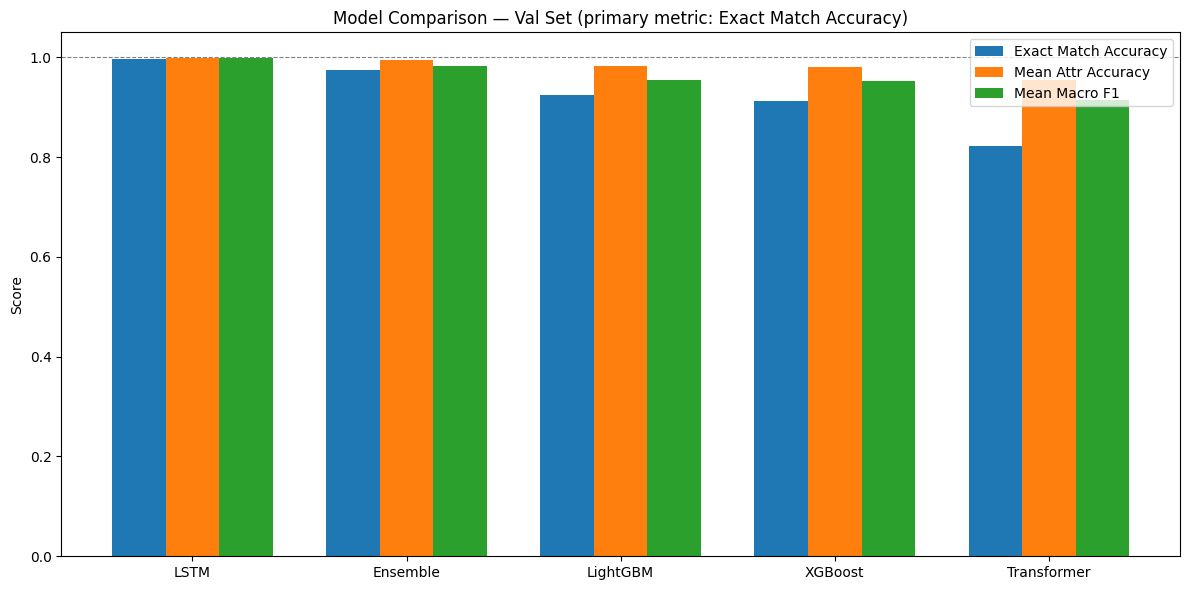

In [15]:
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(comparison_df))
width = 0.25

ax.bar(x - width, comparison_df['Exact Match Accuracy'],    width, label='Exact Match Accuracy')
ax.bar(x,         comparison_df['Mean Attribute Accuracy'], width, label='Mean Attr Accuracy')
ax.bar(x + width, comparison_df['Mean Macro F1'],           width, label='Mean Macro F1')

ax.set_ylabel('Score')
ax.set_title('Model Comparison — Val Set (primary metric: Exact Match Accuracy)')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'])
ax.legend()
ax.set_ylim(0, 1.05)
ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.savefig('../outputs/figures/model_comparison.png', dpi=150)
plt.show()

## Submission Generation

Submission is generated by predicting `X_test` with the best model trained on `X_train`.
`merge_train_val()` is **never called** — `X_val` / `Y_val` are not combined with training data.

In [16]:
# Select best model by exact-match accuracy on val set
best_model_name = comparison_df.iloc[0]['Model']
best_exact_match = comparison_df.iloc[0]['Exact Match Accuracy']
print(f"Best model: {best_model_name}  (val exact-match={best_exact_match:.4f})")

# Map model name to (model_object, X_test_input)
model_input_map = {
    'XGBoost':     (xgb_model,         X_test_features),
    'LightGBM':    (lgb_wrapper,       X_test_features),
    'LSTM':        (lstm_model,        X_test_seq),
    'Transformer': (transformer_model, X_test_seq),
    'Ensemble':    (None, None),
}

if best_model_name == 'Ensemble':
    test_predictions_encoded = ensemble_model.predict_from_inputs(
        [X_test_features, X_test_features, X_test_seq, X_test_seq]
    )
else:
    best_model_obj, X_test_input = model_input_map[best_model_name]
    test_predictions_encoded = best_model_obj.predict(X_test_input)

# Inverse-transform encoded indices back to original uint16 class values
test_predictions_df = target_encoder.inverse_transform(test_predictions_encoded)

submission = pd.DataFrame({'id': test_ids})
for col in DataLoader.TARGET_COLS:
    submission[col] = test_predictions_df[col].astype(np.uint16)

submission.to_csv('../outputs/submissions/submission.csv', index=False)
print(f"Submission saved to ../outputs/submissions/submission.csv | shape={submission.shape}")
print(submission.head())

Best model: LSTM  (val exact-match=0.9962)
Submission saved to ../outputs/submissions/submission.csv | shape=(38000, 7)
      id  attr_1  attr_2  attr_3  attr_4  attr_5  attr_6
0  gpbfd      11       1      84      12       1      96
1  w22ee       9      19      55       3      12      63
2  wyw95       1       1      98       3       1      53
3  izx4w       5       1      72       1       1      77
4  c6o2d      11       1      22      12       1       1


In [17]:
# Save all models and preprocessors
xgb_model.save('../outputs/models/xgboost_model.pkl')
lstm_model.save('../outputs/models/lstm_model.pkl')
transformer_model.save('../outputs/models/transformer_model.pkl')

import pickle
with open('../outputs/models/lgb_models.pkl', 'wb') as f:
    pickle.dump(lgb_models, f)

print("All models and preprocessors saved.")

2026-03-02 16:08:11,203 - src.models.base_model - INFO - Saved model to ../outputs/models/xgboost_model.pkl
2026-03-02 16:08:11,231 - src.models.base_model - INFO - Saved model to ../outputs/models/lstm_model.pkl
2026-03-02 16:08:11,254 - src.models.base_model - INFO - Saved model to ../outputs/models/transformer_model.pkl


All models and preprocessors saved.


## Summary

### Data Policy Compliance Checklist

- [x] `SequencePreprocessor`, `FeaturePipeline`, `TargetEncoder` fit only on `X_train` / `Y_train`
- [x] Early stopping uses **internal 90/10 split from `X_train`** for ALL models (XGBoost, LightGBM, LSTM, Transformer)
- [x] `Y_val` never passed to any `.fit()` call — used only for post-training evaluation
- [x] `merge_train_val()` never called
- [x] Submission generated from `predict(X_test)` with model trained on `X_train` only

### Models Trained

| # | Model | Family | Input |
|---|-------|--------|-------|
| 1 | XGBoost | ML | FeaturePipeline (TF-IDF + stats + histogram) |
| 2 | LightGBM | ML | FeaturePipeline (TF-IDF + stats + histogram) |
| 3 | LSTM (Bidirectional + Attention) | DL | Padded sequences (len=64) |
| 4 | Transformer (CLS token) | Transformer | Padded sequences (len=64) |
| 5 | Ensemble (weighted soft-voting) | Ensemble | All of the above |

### Next Steps

- Run `python train_cv.py --models xgboost --n_folds 5` for K-Fold CV score estimate
- Tune hyperparameters in `configs/config.yaml`
- Submit with `python predict.py --model ensemble --team_name your_team`